#ToDo
- Add vresutils to env
- Add more scenarios
- Also try 100
- Continue with Curtailment

In [3]:
import pypsa
import yaml
import cartopy
import sys
import re
import os

import pandas as pd
import numpy as np
import geopandas as gpd
import xarray as xr
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib as mpl

from itertools import product
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches
from matplotlib.transforms import Bbox

from vresutils.costdata import annuity #H2G-A: ToDo: Add vresutils to env

PATH = "../../../pypsa-eur/"

sys.path.append(os.path.join(PATH, "scripts/"))
from _helpers import rename_techs

plt.style.use(["bmh", "matplotlibrc"])
xr.set_options(display_style="html")

%matplotlib inline

ModuleNotFoundError: No module named '_helpers'

In [22]:
CLUSTERS = 39
LV_OPTS = "Co2L0-144H-T-H-B-I-A-solar+p3-linemaxext10-onwind+p0"
OUTPUT = "../results/graphics-test/"

MAIN_SCENARIOS = PATH + "results/fneum-h2-network-main" #H2G-A: ToDo: Add more scenarios
DEC_SCENARIOS = PATH + "results/fneum-h2-network-main"

#LV_SCENARIOS = PATH + "results/20221227-lv"
#ONW_SCENARIOS = PATH + "results/20221227-onw"
#GAS_SCENARIOS = PATH + "results/20221227-gas"
#IMP_SCENARIOS = PATH + "results/20221227-import"
#SHP_SCENARIOS = PATH + "results/20221227-shipping"
#COST_SCENARIOS = PATH + "results/20221227-costs"
#TIME_SCENARIOS = PATH + "results/20221227-time"
#SPACE_SCENARIOS = PATH + "results/20221227-spatial"
#OLD_SCENARIOS = "../workflows-rev0/pypsa-eur-sec/results/20211218-181-h2"


with open("../../config/config.fneum_h2_network_main.yaml") as file:
    config = yaml.safe_load(file)

In [23]:
latex = {}

In [24]:
tech_colors = config["plotting"]["tech_colors"]

In [25]:
tech_colors["battery electric vehicles"] = tech_colors["BEV charger"]
tech_colors["other"] = "#454545"
tech_colors["building heat demand"] = tech_colors["heat"]
tech_colors["ambient heat"] = tech_colors["heat pump"]
tech_colors["residential electricity demand"] = "#72709c"
tech_colors["industry electricity demand"] = tech_colors["electricity"]
tech_colors["hydrogen demand"] = tech_colors["land transport fuel cell"]
tech_colors["agriculture machinery"] = tech_colors["land transport fuel cell"]
tech_colors["methane demand"] = tech_colors["methane"] #H2G-A: Double check
tech_colors["liquid hydrocarbon demand"] = tech_colors["kerosene for aviation"]
tech_colors["aviation fuels"] = tech_colors["kerosene for aviation"]
tech_colors["shipping fuels"] = tech_colors["shipping methanol"]
tech_colors["biomass demand"] = tech_colors["biogas"]
tech_colors["biogas upgrading"] = tech_colors["biogas"]
tech_colors["hydrogen for industry"] = tech_colors["H2 for industry"]
tech_colors["hydrogen-to-power/heat"] = tech_colors["gas-to-power/heat"]
tech_colors["hydrogen for land transport"] = "#8487e8"

In [26]:
if not os.path.exists(OUTPUT):
    os.makedirs(OUTPUT)

In [27]:
def rename_techs_tyndp(tech):
    tech = rename_techs(tech)
    if "heat pump" in tech or "resistive heater" in tech:
        return "power-to-heat"
    elif tech in ["H2 Electrolysis"]:  # , "H2 liquefaction"]:
        return "power-to-hydrogen"
    elif "H2 pipeline" in tech:
        return "H2 pipeline"
    elif tech == "H2":
        return "H2 storage"
    elif tech in ["OCGT", "CHP", "gas boiler", "H2 Fuel Cell"]:
        return "gas-to-power/heat"
    # elif "solar" in tech:
    #    return "solar"
    elif tech in ["Fischer-Tropsch", "methanolisation"]:
        return "power-to-liquid"
    elif "offshore wind" in tech:
        return "offshore wind"
    elif "SMR" in tech:
        return tech.replace("SMR", "steam methane reforming")
    elif "DAC" in tech:
        return "direct air capture"
    elif "CC" in tech or "sequestration" in tech:
        return "carbon capture"
    elif tech == "oil" or tech == "gas":
        return "fossil oil and gas"
    else:
        return tech

In [28]:
def rename_techs_balances(tech):
    tech = rename_techs(tech)
    if "heat pump" in tech:
        return "ambient heat"
    elif tech in ["H2 Electrolysis"]:  # , "H2 liquefaction"]:
        return "power-to-hydrogen"
    elif "solar" in tech:
        return "solar"
    elif tech in ["Fischer-Tropsch", "methanolisation"]:
        return "power-to-liquid"
    elif tech == "DAC":
        return "direct air capture"
    elif "offshore wind" in tech:
        return "offshore wind"
    elif tech == "oil" or tech == "gas":
        return "fossil oil and gas"
    elif tech in ["BEV charger", "V2G", "Li ion", "land transport EV"]:
        return "battery electric vehicles"
    elif tech in ["biogas", "solid biomass"]:
        return "biomass"
    elif tech in ["electricity"]:
        return "residential electricity demand"
    elif tech in ["industry electricity", "agriculture electricity"]:
        return "industry electricity demand"
    elif tech in ["agriculture heat", "heat", "low-temperature heat for industry"]:
        return "heat demand"
    elif "solid biomass for industry" in tech:
        return "biomass demand"
    elif "gas for industry" in tech:
        return "methane demand"
    elif tech in ["H2 for industry", "land transport fuel cell"]:
        return "hydrogen demand"
    elif tech in [
        "kerosene for aviation",
        "naphtha for industry",
        "shipping methanol",
        "agriculture machinery oil",
    ]:
        return "liquid hydrocarbon demand"
    elif tech in [
        "transmission lines",
        "H2 pipeline",
        "H2 pipeline retrofitted",
        "H2",
        "electricity distribution grid",
        "SMR",
        "SMR CC",
        "OCGT",
        "CHP",
        "gas boiler",
        "H2 Fuel Cell",
        "resistive heater",
        "battery storage",
        "methanation",
    ]:
        return "other"
    else:
        return tech

In [29]:
def rename_techs_carbon_balances(tech):
    prefix_to_remove = [
        "residential ",
        "services ",
        "urban ",
        "rural ",
        "central ",
        "decentral ",
    ]
    for ptr in prefix_to_remove:
        if tech[: len(ptr)] == ptr:
            tech = tech[len(ptr) :]
    if tech == "biogas to gas":
        return "biogas upgrading"
    elif tech == "agriculture machinery oil emissions":
        return "agriculture machinery"
    elif tech == "shipping methanol emissions":
        return "shipping fuels"
    elif tech == "DAC":
        return "direct air capture"
    elif "SMR" in tech:
        return tech.replace("SMR", "steam methane reforming")
    else:
        return tech

In [30]:
preferred_order = pd.Index(
    [
        "transmission lines",
        "electricity distribution grid",
        "fossil oil and gas",
        "hydroelectricity",
        "hydro reservoir",
        "run of river",
        "pumped hydro storage",
        "solid biomass",
        "biogas",
        "onshore wind",
        "offshore wind",
        "offshore wind (AC)",
        "offshore wind (DC)",
        "solar PV",
        "solar thermal",
        "solar rooftop",
        "solar",
        "building retrofitting",
        "ground heat pump",
        "air heat pump",
        "heat pump",
        "resistive heater",
        "power-to-heat",
        "gas-to-power/heat",
        "CHP",
        "OCGT",
        "gas boiler",
        "gas",
        "natural gas",
        "helmeth",
        "methanation",
        "power-to-gas",
        "power-to-hydrogen",
        "H2 pipeline",
        "H2 liquefaction",
        "H2 storage",
        "hydrogen storage",
        "power-to-liquid",
        "battery storage",
        "hot water storage",
        "CO2 sequestration",
        "CCS",
        "carbon capture and sequestration",
        "DAC",
        "direct air capture",
    ]
)

In [31]:
def parse_index(c, with_resolution=False):
    clusters = c[0]

    lv = c[1]

    match = re.search(r"onwind\+p([0-9.]*)", c[2])
    onw = 100.0 if match is None else 100 * float(match.groups()[0])

    h2 = "no H2 grid" if "noH2network" in c[2] else "H2 grid"

    to_return = (clusters, lv, onw, h2)

    if with_resolution:
        match = re.findall(r"(\d+)H", c[2])
        to_return += (int(match[0]),)

    return to_return

In [32]:
def load_decentral():
    costs = pd.read_csv(
        DEC_SCENARIOS + "/csvs/costs.csv", header=[0, 1, 2, 3], index_col=[0, 1, 2]
    )

    costs = costs.xs("2050", level="planning_horizon", axis=1)

    costs.columns = pd.MultiIndex.from_tuples(
        [parse_index(c) for c in costs.columns], names=["clusters", "lv", "onw", "h2"]
    )

    costs = costs.xs(str(CLUSTERS), level="clusters", axis=1)

    df = costs.groupby(level=2).sum().div(1e9)

    df = df.groupby(df.index.map(rename_techs_tyndp)).sum()

    df = df.xs(100, level="onw", axis=1, drop_level=False)

    df.sum() / df.sum().min()

    to_drop = df.index[df.max(axis=1).fillna(0.0) < 1.2]
    print(to_drop)
    df.drop(to_drop, inplace=True)

    order = preferred_order.intersection(df.index).append(
        df.index.difference(preferred_order)
    )
    df = df.loc[order]

    tech_colors = config["plotting"]["tech_colors"]
    colors = [tech_colors[i] for i in df.index]

    df.columns = df.columns.get_level_values(2)
    df.columns.name = ""

    return df

In [33]:
def load_main(
    scenarios=None, clusters=None, rename=True, with_resolution=False, with_space=False
):
    if scenarios is None:
        scenarios = MAIN_SCENARIOS

    if clusters is None:
        clusters = CLUSTERS

    horizon = "2030" if "rev0" in scenarios else "2050"

    costs = pd.read_csv(
        scenarios + f"/csvs/costs.csv", header=[0, 1, 2, 3], index_col=[0, 1, 2]
    )

    costs = costs.xs(horizon, level="planning_horizon", axis=1)

    names = ["clusters", "lv", "onw", "h2"]
    if with_resolution:
        names += ("res",)

    costs.columns = pd.MultiIndex.from_tuples(
        [parse_index(c, with_resolution) for c in costs.columns], names=names
    )

    if not with_space:
        costs = costs.xs(str(clusters), level="clusters", axis=1)

    df = costs.groupby(level=2).sum().div(1e9)

    if rename:
        df = df.groupby(df.index.map(rename_techs_tyndp)).sum()

    to_drop = df.index[df.max(axis=1).fillna(0.0) < 1.2]
    print(to_drop)
    df.drop(to_drop, inplace=True)

    order = preferred_order.intersection(df.index).append(
        df.index.difference(preferred_order)
    )
    df = df.loc[order]

    if "-imp" in scenarios:
        # imports for methanol, kerosene and naphtha at 120 €/MWh
        print("add import costs")
        df.loc["green e-fuel imports"] = (1026.64 + 546.36) * 120e6 / 1e9  # bn€/a
        tech_colors["green e-fuel imports"] = "#46caf0"

    return df

In [34]:
def load_main_capacities(
    scenarios=None,
    clusters=None,
    rename=True,
    with_resolution=False,
    with_space=False,
    merge=True,
):
    if scenarios is None:
        scenarios = MAIN_SCENARIOS

    if clusters is None:
        clusters = CLUSTERS

    horizon = "2030" if "rev0" in scenarios else "2050"

    df = pd.read_csv(
        scenarios + f"/csvs/capacities.csv", header=[0, 1, 2, 3], index_col=[0, 1]
    )

    df = df.xs(horizon, level="planning_horizon", axis=1)

    names = ["clusters", "lv", "onw", "h2"]
    if with_resolution:
        names += ("res",)

    df.columns = pd.MultiIndex.from_tuples(
        [parse_index(c, with_resolution) for c in df.columns], names=names
    )

    if not with_space:
        df = df.xs(str(clusters), level="clusters", axis=1)

    if rename:
        grouper = [
            df.index.get_level_values(0),
            df.index.get_level_values(1).map(rename_techs_tyndp),
        ]
        df = df.groupby(grouper).sum()

    to_drop = df.index[df.max(axis=1).fillna(0.0) < 10]
    df.drop(to_drop, inplace=True)

    twh = df.xs("stores", level=0).div(1e6)  # TWh

    to_drop = [
        "CCS",
        "biogas",
        "co2",
        "fossil oil and gas",
        "solid biomass",
    ]
    twh.drop(twh.index.intersection(to_drop), inplace=True)

    gw = df.drop(["stores", "lines"]).div(1e3)  # GW

    if merge:
        gw = gw.groupby(level=1).sum()
        techs = gw.index
        kwargs = dict()
    else:
        techs = gw.index.levels[1]
        kwargs = dict(level=1)

    to_drop = [
        "fossil oil and gas",
        "transmission lines",
        "DAC",
        "direct air capture",
        "H2 pipeline",
        "H2 pipeline retrofitted",
        "CCS",
        "carbon capture" "biogas",
        "gas for industry",
        "hot water storage",
        "solid biomass for industry",
        "process emissions",
    ]
    gw.drop(techs.intersection(to_drop), **kwargs, inplace=True)

    return gw, twh

In [35]:
def load_main_energy(
    scenarios=None, clusters=None, rename=True, with_resolution=False, with_space=False
):
    if scenarios is None:
        scenarios = MAIN_SCENARIOS

    if clusters is None:
        clusters = CLUSTERS

    horizon = "2030" if "rev0" in scenarios else "2050"

    df = pd.read_csv(
        scenarios + f"/csvs/energy.csv", header=[0, 1, 2, 3], index_col=[0, 1]
    )

    df = df.xs(horizon, level="planning_horizon", axis=1)

    names = ["clusters", "lv", "onw", "h2"]
    if with_resolution:
        names += ("res",)

    df.columns = pd.MultiIndex.from_tuples(
        [parse_index(c, with_resolution) for c in df.columns], names=names
    )

    if not with_space:
        df = df.xs(str(clusters), level="clusters", axis=1)

    df = df.groupby(level=1).sum().div(1e6)  # TWh

    if rename:
        df = df.groupby(df.index.map(rename_techs_tyndp)).sum()

    to_drop = df.index[df.abs().max(axis=1).fillna(0.0) < 10]
    df.drop(to_drop, inplace=True)

    order = preferred_order.intersection(df.index).append(
        df.index.difference(preferred_order)
    )
    df = df.loc[order]

    if "-imp" in scenarios:
        # imports for methanol, kerosene and naphtha
        df.loc["green e-fuel imports"] = 1026.64 + 546.36  # TWh
        tech_colors["green e-fuel imports"] = "#46caf0"

    return df

In [36]:
def load_main_cfs(
    scenarios=None, clusters=None, with_resolution=False, with_space=False
):
    if scenarios is None:
        scenarios = MAIN_SCENARIOS

    if clusters is None:
        clusters = CLUSTERS

    horizon = "2030" if "rev0" in scenarios else "2050"

    df = pd.read_csv(
        scenarios + f"/csvs/cfs.csv", header=[0, 1, 2, 3], index_col=[0, 1]
    )

    df = df.xs(horizon, level="planning_horizon", axis=1)

    names = ["clusters", "lv", "onw", "h2"]
    if with_resolution:
        names += ("res",)

    df.columns = pd.MultiIndex.from_tuples(
        [parse_index(c, with_resolution) for c in df.columns], names=names
    )

    if not with_space:
        df = df.xs(str(clusters), level="clusters", axis=1)

    df = df.groupby(level=1).sum()

    return df

In [37]:
def fix_df(df):
    column_dict = {
        "1.0": "w/o power grid expansion",
        "opt": "w power grid expansion",
        "H2 grid": "w hydrogen network",
        "no H2 grid": "w/o hydrogen network",
    }
    df.rename(columns=column_dict, inplace=True)
    df.columns = ["\n".join(col).strip() for col in df.columns.values]
    df.sort_index(axis=1, inplace=True)

In [38]:
def load_main_supply_energy(
    scenarios=None,
    clusters=None,
    rename=True,
    with_resolution=False,
    with_space=False,
    carrier="energy",
):
    if scenarios is None:
        scenarios = MAIN_SCENARIOS

    if clusters is None:
        clusters = CLUSTERS

    horizon = "2030" if "rev0" in scenarios else "2050"

    df = pd.read_csv(
        scenarios + "/csvs/supply_energy.csv", index_col=[0, 1, 2], header=[0, 1, 2, 3]
    )

    co2_carriers = ["co2", "co2 stored", "process emissions"]
    if carrier == "energy":
        carrier = [i for i in df.index.levels[0] if i not in co2_carriers]

    df = df.loc[carrier].groupby(level=2).sum().div(1e6)  # TWh / MtCO2
    df.index = [
        i[:-1]
        if ((i not in ["co2", "NH3", "H2"]) and (i[-1:] in ["0", "1", "2", "3"]))
        else i
        for i in df.index
    ]

    df = df.xs(horizon, level="planning_horizon", axis=1)

    names = ["clusters", "lv", "onw", "h2"]
    if with_resolution:
        names += ("res",)

    df.columns = pd.MultiIndex.from_tuples(
        [parse_index(c, with_resolution) for c in df.columns], names=names
    )

    if not with_space:
        df = df.xs(str(clusters), level="clusters", axis=1)

    if rename or callable(rename):
        func = rename if callable(rename) else rename_techs_tyndp
        df = df.groupby(df.index.map(func)).sum()

    to_drop = df.index[df.abs().max(axis=1).fillna(0.0) < 10]
    df.drop(to_drop, inplace=True)

    order = preferred_order.intersection(df.index).append(
        df.index.difference(preferred_order)
    )
    df = df.loc[order]

    if "-imp" in scenarios and carrier == "energy":
        # imports for methanol, kerosene and naphtha
        df.loc["green e-fuel imports"] = 1026.64 + 546.36  # TWh
        tech_colors["green e-fuel imports"] = "#46caf0"

    return df

In [39]:
def energy_balances(scenarios, onw=100):
    co2_carriers = ["co2", "co2 stored", "process emissions"]

    balances_df = pd.read_csv(
        scenarios + "/csvs/supply_energy.csv", index_col=[0, 1, 2], header=[0, 1, 2, 3]
    )

    balances = {i.replace(" ", "_"): [i] for i in balances_df.index.levels[0]}
    balances["energy"] = [
        i for i in balances_df.index.levels[0] if i not in co2_carriers
    ]
    balances["carbon"] = [i for i in balances_df.index.levels[0] if i in co2_carriers]

    key = "energy"

    df = balances_df.loc[balances[key]]

    df = df.groupby(level=2).sum().div(1e6)

    df.index = [
        i[:-1]
        if ((i not in ["co2", "NH3", "H2"]) and (i[-1:] in ["0", "1", "2", "3"]))
        else i
        for i in df.index
    ]

    df = df.groupby(rename_techs_balances).sum()

    df.columns = pd.MultiIndex.from_tuples(
        [parse_index(c) for c in df.columns], names=["clusters", "lv", "onw", "h2"]
    )

    df = df.xs((onw, str(39)), level=["onw", "clusters"], axis=1) #H2G-A: Changed to 39

    order = pd.Index(
        [
            "fossil oil and gas",
            "hydroelectricity",
            "biomass",
            "offshore wind",
            "onshore wind",
            "solar",
            "ambient heat",
            "residential electricity demand",
            "industry electricity demand",
            "electricity demand",
            "battery electric vehicles",
            "heat demand",
            "hydrogen demand",
            "biomass demand",
            "methane demand",
            "liquid hydrocarbon demand",
            "power-to-liquid",
            "methanation",
            "power-to-hydrogen",
            "hot water storage",
            "direct air capture",
            "other",
        ]
    )

    order = order.intersection(df.index).append(df.index.difference(order))
    df = df.loc[order]

    return df

In [40]:
c = carbon_balances(scenarios, 0) #H2G-A: Add 0

NameError: name 'carbon_balances' is not defined

In [ ]:
scenarios = MAIN_SCENARIOS

onw = 0
co2_carriers = ["Co2"]
#co2_carriers = ["co2", "co2 stored", "process emissions"]

balances_df = pd.read_csv(
    scenarios + "/csvs/supply_energy.csv", index_col=[0, 1, 2], header=[0, 1, 2, 3]
)

balances = {i.replace(" ", "_"): [i] for i in balances_df.index.levels[0]}
balances["energy"] = [
    i for i in balances_df.index.levels[0] if i not in co2_carriers
]
balances["carbon"] = [i for i in balances_df.index.levels[0] if i in co2_carriers]

key = "co2"

df = balances_df.loc[balances[key]]

df = df.groupby(level=2).sum().div(1e6)

df.index = [
    i[:-1]
    if ((i not in ["co2", "NH3", "H2"]) and (i[-1:] in ["0", "1", "2", "3"]))
    else i
    for i in df.index
]

df = df.groupby(rename_techs_carbon_balances).sum()

df.columns = pd.MultiIndex.from_tuples(
    [parse_index(c) for c in df.columns], names=["clusters", "lv", "onw", "h2"]
)

df = df.xs((onw, str(39)), level=["onw", "clusters"], axis=1) #H2G-A: Changed to 39

df.drop("co2", inplace=True)

order = pd.Index(
    [
        "liquid hydrocarbons emissions",
        "methanol emissions",
        "process emissions CC",
        "gas for industry CC",
        "gas CHP CC",
        "gas CHP",
        "OCGT",
        "gas boiler",
        "steam methane reforming",
        "steam methane reforming CC",
        "biogas upgrading",
        "solid biomass CHP CC",
        "solid biomass for industry CC",
        "direct air capture",
    ]
)

order = order.intersection(df.index).append(df.index.difference(order))
df = df.loc[order]

df = df.loc[df.abs().max(axis=1) > 0.01]

In [ ]:
def carbon_balances(scenarios, onw=100):
    co2_carriers = ["co2", "co2 stored", "process emissions"]

    balances_df = pd.read_csv(
        scenarios + "/csvs/supply_energy.csv", index_col=[0, 1, 2], header=[0, 1, 2, 3]
    )

    balances = {i.replace(" ", "_"): [i] for i in balances_df.index.levels[0]}
    balances["energy"] = [
        i for i in balances_df.index.levels[0] if i not in co2_carriers
    ]
    balances["carbon"] = [i for i in balances_df.index.levels[0] if i in co2_carriers]

    key = "co2"

    df = balances_df.loc[balances[key]]

    df = df.groupby(level=2).sum().div(1e6)

    df.index = [
        i[:-1]
        if ((i not in ["co2", "NH3", "H2"]) and (i[-1:] in ["0", "1", "2", "3"]))
        else i
        for i in df.index
    ]

    df = df.groupby(rename_techs_carbon_balances).sum()

    df.columns = pd.MultiIndex.from_tuples(
        [parse_index(c) for c in df.columns], names=["clusters", "lv", "onw", "h2"]
    )

    df = df.xs((onw, str(39)), level=["onw", "clusters"], axis=1) #H2G-A: Changed to 39

    df.drop("co2", inplace=True)

    order = pd.Index(
        [
            "liquid hydrocarbons emissions",
            "methanol emissions",
            "process emissions CC",
            "gas for industry CC",
            "gas CHP CC",
            "gas CHP",
            "OCGT",
            "gas boiler",
            "steam methane reforming",
            "steam methane reforming CC",
            "biogas upgrading",
            "solid biomass CHP CC",
            "solid biomass for industry CC",
            "direct air capture",
        ]
    )

    order = order.intersection(df.index).append(df.index.difference(order))
    df = df.loc[order]

    df = df.loc[df.abs().max(axis=1) > 0.01]

    return df

In [ ]:
def rename_techs_h2_balances(tech):
    if tech == "H2 for industry":
        return "hydrogen for industry"
    elif tech == "Sabatier":
        return "methanation"
    elif tech == "H2 Electrolysis":
        return "power-to-hydrogen"
    elif tech == "land transport fuel cell":
        return "hydrogen for land transport"
    elif tech == "H2 Fuel Cell":
        return "hydrogen-to-power/heat"
    elif "SMR" in tech:
        return tech.replace("SMR", "steam methane reforming")
    else:
        return tech

## Dashboard Export

In [4]:
SCENARIOS = {
    (0, 0, 0, 0): (MAIN_SCENARIOS, 0), #H2G-A: ToDo: Also try 100
    (1, 0, 0, 0): (MAIN_SCENARIOS, 0), #H2G-A: ToDo: Also try 100
    (0, 1, 0, 0): (MAIN_SCENARIOS, 0), #H2G-A: ToDo: Also try 100
    (0, 0, 1, 0): (MAIN_SCENARIOS, 0), #H2G-A: ToDo: Also try 100
    (0, 0, 0, 1): (MAIN_SCENARIOS, 0), #H2G-A: ToDo: Also try 100
}

NAMES = ["main_scenario", "main_scenario", "main_scenario", "main_scenario"]

NameError: name 'MAIN_SCENARIOS' is not defined

In [ ]:
SCENARIOS

{(0, 0, 0, 0): ('../../../pypsa-eur/results/fneum-h2-network-main', 0),
 (1, 0, 0, 0): ('../../../pypsa-eur/results/fneum-h2-network-main', 0),
 (0, 1, 0, 0): ('../../../pypsa-eur/results/fneum-h2-network-main', 0),
 (0, 0, 1, 0): ('../../../pypsa-eur/results/fneum-h2-network-main', 0),
 (0, 0, 0, 1): ('../../../pypsa-eur/results/fneum-h2-network-main', 0)}

In [ ]:
tsc = pd.concat(
    {
        k: load_main(scenarios).xs(onw, level="onw", axis=1)
        for k, (scenarios, onw) in SCENARIOS.items()
    },
    names=NAMES,
)

Index(['BEV charger', 'H2 pipeline', 'V2G', 'agriculture machinery oil',
       'battery storage', 'co2', 'fossil oil and gas', 'gas for industry',
       'industry methanol', 'kerosene for aviation', 'methanation', 'methanol',
       'naphtha for industry', 'oil refining', 'process emissions',
       'shipping methanol', 'solid biomass for industry',
       'steam methane reforming', 'steam methane reforming CC'],
      dtype='object')
Index(['BEV charger', 'H2 pipeline', 'V2G', 'agriculture machinery oil',
       'battery storage', 'co2', 'fossil oil and gas', 'gas for industry',
       'industry methanol', 'kerosene for aviation', 'methanation', 'methanol',
       'naphtha for industry', 'oil refining', 'process emissions',
       'shipping methanol', 'solid biomass for industry',
       'steam methane reforming', 'steam methane reforming CC'],
      dtype='object')
Index(['BEV charger', 'H2 pipeline', 'V2G', 'agriculture machinery oil',
       'battery storage', 'co2', 'fossil oil 

In [ ]:
tsc

lv                                                                                          vopt
h2                                                                                       H2 grid
main_scenario main_scenario main_scenario main_scenario                                         
0             0             0             0             transmission lines             23.771896
                                                        electricity distribution grid  36.078045
                                                        hydroelectricity               43.443426
                                                        solid biomass                  14.038163
                                                        biogas                         30.702012
...                                                                                          ...
                                          1             carbon capture                 16.950713
                                                        co2 sequestered                 2.019925
                                                        nuclear                        91.416324
                                                        oil primary                    15.036860
                                                        solar-hsat                     20.146403

[105 rows x 1 columns]

In [ ]:
tsc.index.names = tsc.index.names[:-1] + ["carrier"]

In [ ]:
tsc

lv                                                                                          vopt
h2                                                                                       H2 grid
main_scenario main_scenario main_scenario main_scenario carrier                                 
0             0             0             0             transmission lines             23.771896
                                                        electricity distribution grid  36.078045
                                                        hydroelectricity               43.443426
                                                        solid biomass                  14.038163
                                                        biogas                         30.702012
...                                                                                          ...
                                          1             carbon capture                 16.950713
                                                        co2 sequestered                 2.019925
                                                        nuclear                        91.416324
                                                        oil primary                    15.036860
                                                        solar-hsat                     20.146403

[105 rows x 1 columns]

In [ ]:
tsc = tsc.stack([0, 1]).to_xarray()
tsc.name = "costs"

/tmp/ipykernel_26387/315578863.py:1: FutureWarning:

The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.

/home/alex-charly/anaconda3/envs/H2_network-fneum/lib/python3.10/site-packages/xarray/namedarray/core.py:496: UserWarning:

Duplicate dimension names present: dimensions {'main_scenario'} appear more than once in dims=('main_scenario', 'main_scenario', 'main_scenario', 'main_scenario', 'carrier', 'lv', 'h2'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediately to become distinct, as most xarray functionality is likely to fail silently if you do not. To rename the dimensions you will need to set the ``.dims`` attribute of each variable, ``e.g. var.dims=('x0', 'x1')``.



In [ ]:
tsc

<xarray.DataArray 'costs' (main_scenario: 2, carrier: 21, lv: 1, h2: 1)> Size: 3kB
array([[[[[[[ 23.77189613]],

           [[ 36.07804545]],

           [[ 43.44342583]],

           [[ 14.03816302]],

           [[ 30.70201213]],

           [[103.82537329]],

           [[ 64.91482295]],

           [[ 94.26866061]],

           [[ 35.92380469]],

           [[ 71.30032061]],

...

           [[         nan]],

           [[         nan]],

           [[         nan]],

           [[         nan]],

           [[         nan]],

           [[         nan]],

           [[         nan]],

           [[         nan]],

           [[         nan]],

           [[         nan]]]]]]])
Coordinates:
  * main_scenario  (main_scenario) int64 16B 0 1
  * carrier        (carrier) object 168B 'transmission lines' ... 'solar-hsat'
  * lv             (lv) object 8B 'vopt'
  * h2             (h2) object 8B 'H2 grid'

In [ ]:
energy = pd.concat(
    {
        k: load_main_supply_energy(scenarios).xs(onw, level="onw", axis=1)
        for k, (scenarios, onw) in SCENARIOS.items()
    },
    names=NAMES,
)

In [ ]:
energy.index.names = energy.index.names[:-1] + ["carrier"]
energy = energy.stack([0, 1]).to_xarray()
energy.name = "energy"

/tmp/ipykernel_26387/2087312535.py:2: FutureWarning:

The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.

/home/alex-charly/anaconda3/envs/H2_network-fneum/lib/python3.10/site-packages/xarray/namedarray/core.py:496: UserWarning:

Duplicate dimension names present: dimensions {'main_scenario'} appear more than once in dims=('main_scenario', 'main_scenario', 'main_scenario', 'main_scenario', 'carrier', 'lv', 'h2'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediately to become distinct, as most xarray functionality is likely to fail silently if you do not. To rename the dimensions you will need to set the ``.dims`` attribute of each variable, ``e.g. var.dims=('x0', 'x1')``.



In [ ]:
energy

<xarray.DataArray 'energy' (main_scenario: 2, carrier: 36, lv: 1, h2: 1)> Size: 5kB
array([[[[[[[ -104.13184327]],

           [[ -141.07483894]],

           [[   20.13621475]],

           [[  497.99920614]],

           [[ 1027.83937516]],

           [[  340.97075936]],

           [[ 2376.33666374]],

           [[ 1396.64454197]],

           [[ 2544.41067101]],

           [[  923.41778837]],

...

           [[           nan]],

           [[           nan]],

           [[           nan]],

           [[           nan]],

           [[           nan]],

           [[           nan]],

           [[           nan]],

           [[           nan]],

           [[           nan]],

           [[           nan]]]]]]])
Coordinates:
  * main_scenario  (main_scenario) int64 16B 0 1
  * carrier        (carrier) object 288B 'transmission lines' ... 'solid biom...
  * lv             (lv) object 8B 'vopt'
  * h2             (h2) object 8B 'H2 grid'

In [ ]:
co2 = pd.concat(
    {k: carbon_balances(scenarios, onw) for k, (scenarios, onw) in SCENARIOS.items()},
    names=NAMES,
)

In [ ]:
co2.index.names = co2.index.names[:-1] + ["carrier"]
co2 = co2.stack([0, 1]).to_xarray()
co2.name = "co2"

/tmp/ipykernel_26387/4110876348.py:2: FutureWarning:

The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.

/home/alex-charly/anaconda3/envs/H2_network-fneum/lib/python3.10/site-packages/xarray/namedarray/core.py:496: UserWarning:

Duplicate dimension names present: dimensions {'main_scenario'} appear more than once in dims=('main_scenario', 'main_scenario', 'main_scenario', 'main_scenario', 'carrier', 'lv', 'h2'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediately to become distinct, as most xarray functionality is likely to fail silently if you do not. To rename the dimensions you will need to set the ``.dims`` attribute of each variable, ``e.g. var.dims=('x0', 'x1')``.



In [ ]:
def read_capacities(scenarios, onw):
    gw, twh = load_main_capacities(scenarios, merge=False)

    gw = gw.xs(onw, level="onw", axis=1)
    twh = twh.xs(onw, level="onw", axis=1)

    gen = gw.loc[["generators", "storage_units"]].groupby(level=1).sum()

    con = gw.loc[["links"]].groupby(level=1).sum()
    return gen, con, twh

In [ ]:
cap = pd.concat(
    {
        k: pd.concat(
            read_capacities(scenarios, onw),
            keys=["generation", "conversion", "storage"],
        )
        for k, (scenarios, onw) in SCENARIOS.items()
    },
    names=NAMES,
)

In [ ]:
cap.index.names = cap.index.names[:-2] + ["category", "carrier"]
cap = cap.stack([0, 1]).unstack("category").to_xarray()

/tmp/ipykernel_26387/3347020266.py:2: FutureWarning:

The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.

/home/alex-charly/anaconda3/envs/H2_network-fneum/lib/python3.10/site-packages/xarray/namedarray/core.py:496: UserWarning:

Duplicate dimension names present: dimensions {'main_scenario'} appear more than once in dims=('main_scenario', 'main_scenario', 'main_scenario', 'main_scenario', 'carrier', 'lv', 'h2'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediately to become distinct, as most xarray functionality is likely to fail silently if you do not. To rename the dimensions you will need to set the ``.dims`` attribute of each variable, ``e.g. var.dims=('x0', 'x1')``.



In [ ]:
ds = xr.merge([tsc, energy, co2, cap]).round(2)

/home/alex-charly/anaconda3/envs/H2_network-fneum/lib/python3.10/site-packages/xarray/namedarray/core.py:496: UserWarning:

Duplicate dimension names present: dimensions {'main_scenario'} appear more than once in dims=('main_scenario', 'main_scenario', 'main_scenario', 'main_scenario', 'carrier', 'lv', 'h2'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediately to become distinct, as most xarray functionality is likely to fail silently if you do not. To rename the dimensions you will need to set the ``.dims`` attribute of each variable, ``e.g. var.dims=('x0', 'x1')``.

/home/alex-charly/anaconda3/envs/H2_network-fneum/lib/python3.10/site-packages/xarray/namedarray/core.py:496: UserWarning:

Duplicate dimension names present: dimensions {'main_scenario'} appear more than once in dims=('main_scenario', 'main_scenario', 'main_scenario', 'main_scenario', 'carrier', 'lv', 'h2'). We do not yet suppor

In [ ]:
comp = dict(zlib=True, complevel=9)
encoding = {var: comp for var in ds.data_vars}
ds.to_netcdf("scenarios.nc", encoding=encoding)

## Balances

In [ ]:
scenarios = MAIN_SCENARIOS

In [ ]:
e = energy_balances(scenarios, 0) #ToDo: Also try 100

In [ ]:
e

lv,vopt
h2,H2 grid
fossil oil and gas,2.013621e+01
hydroelectricity,4.979992e+02
biomass,1.368810e+03
offshore wind,1.396645e+03
onshore wind,2.376337e+03
solar,4.020185e+03
ambient heat,1.818868e+03
residential electricity demand,-1.574975e+03
industry electricity demand,-1.794646e+03


In [ ]:
h = load_main_supply_energy(
    scenarios, carrier=["H2"], rename=rename_techs_h2_balances
).xs(0, level="onw", axis=1) #H2G-A: Add 0

order = pd.Index(
    [
        "power-to-hydrogen",
        "steam methane reforming CC",
        "Fischer-Tropsch",
        "methanolisation",
        "hydrogen for industry",
        "hydrogen for land transport",
        "hydrogen-to-power/heat",
    ]
)

order = order.intersection(h.index).append(h.index.difference(order))
h = h.loc[order]

In [ ]:
h

lv,vopt
h2,H2 grid
power-to-hydrogen,1872.245389
Fischer-Tropsch,-1112.026934
methanolisation,-582.348589
hydrogen for industry,-177.870000


In [ ]:
scenarios

'../../../pypsa-eur/results/fneum-h2-network-main'

In [ ]:
c = carbon_balances(scenarios, 0) #H2G-A: Add 0

In [ ]:
fn = (
    f"../../../pypsa-eur/resources/fneum-h2-network-main/industrial_energy_demand_base_s_39_2050.csv" #H2G-A
)
industrial_demand = pd.read_csv(fn, index_col=0)

In [ ]:
plastics = (
    industrial_demand["naphtha"].sum() * 0.26
    - industrial_demand["process emission from feedstock"].sum()
)

In [ ]:
fn = f"../../../pypsa-eur/resources/fneum-h2-network-main/energy_totals.csv" #H2G-A
energy_totals = pd.read_csv(fn, index_col=0)

In [ ]:
aviation = (
    energy_totals[["total international aviation", "total domestic aviation"]]
    .sum()
    .sum()
    * 0.26
)

In [ ]:
#c.drop("oil emissions", inplace=True) #H2G-A: Changed
c.loc["aviation fuels"] = aviation
c.loc["high-value chemicals"] = plastics

In [ ]:
other = c.abs().max(axis=1) < 10
to_drop = c.loc[other].index
c.loc["other"] = c.loc[other].sum()
c.drop(to_drop, axis=0, inplace=True)

In [ ]:
order = pd.Index(
    [
        "aviation fuels",
        "shipping fuels",
        "high-value chemicals",
        "agriculture machinery",
        "process emissions CC",
        "gas for industry CC",
        "gas CHP",
        "gas boiler",
        "other",
        "biogas upgrading",
        "solid biomass CHP CC",
        "solid biomass for industry CC",
        "direct air capture",
    ]
)

order = order.intersection(c.index).append(c.index.difference(order))
c = c.loc[order]

In [ ]:
column_dict = {
    "1.0": "w/o power",
    "opt": "w power",
    "H2 grid": "w H$_2$",
    "no H2 grid": "w/o H$_2$",
}


c.rename(columns=column_dict, inplace=True)
e.rename(columns=column_dict, inplace=True)
h.rename(columns=column_dict, inplace=True)

sep = "\n"
c.columns = [sep.join(col).strip() for col in c.columns.values]
e.columns = [sep.join(col).strip() for col in e.columns.values]
h.columns = [sep.join(col).strip() for col in h.columns.values]

c.sort_index(axis=1, inplace=True)
e.sort_index(axis=1, inplace=True)
h.sort_index(axis=1, inplace=True)

In [ ]:
# H2G-A: Changed
tech_colors["fossil oil and gas"] = "#e05b09"
tech_colors["power-to-hydrogen"] = "#e05b09"
tech_colors["direct air capture"] = "#e05b09"
tech_colors["methanolisation4"] = "#e05b09"

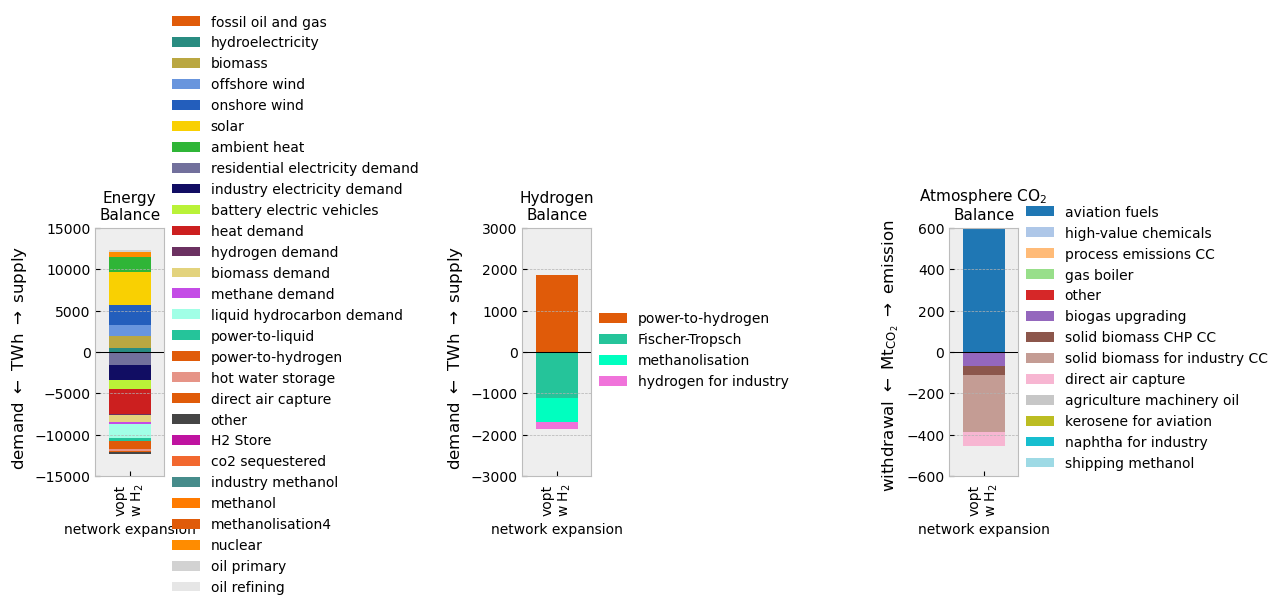

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13, 5.2))

lim = 15000
e.T.plot.bar(ax=ax1, width=0.8, stacked=True, color=tech_colors, ylim=(-lim, lim))

c.T.plot.bar(ax=ax3, width=0.8, stacked=True, cmap="tab20", ylim=(-600, 600))

h.T.plot.bar(ax=ax2, width=0.8, stacked=True, color=tech_colors, ylim=(-3000, 3000))

ax1.legend(loc=(1.03, -0.5), ncol=1)
ax2.legend(loc=(1.03, 0.33))
ax3.legend(loc=(1.03, -0.0))

for ax in [ax1, ax2, ax3]:
    for tick in ax.get_xticklabels():
        tick.set_rotation(90)
    ax.axhline(0, color="k", linewidth=0.75)
    ax.xaxis.set_tick_params(pad=5)
    ax.set_xlabel("network expansion", fontsize=10)
    ax.grid(axis="y")


ax1.set_ylabel(r"demand $\leftarrow$ TWh $\rightarrow$ supply   ")
ax3.set_ylabel(r"withdrawal $\leftarrow$ Mt$_{CO_2}$ $\rightarrow$ emission  ")
ax2.set_ylabel(r"demand $\leftarrow$ TWh $\rightarrow$ supply   ")

ax1.set_title("Energy\nBalance", fontsize=11)
ax3.set_title(r"Atmosphere CO$_2$" + "\nBalance", fontsize=11)
ax2.set_title("Hydrogen\nBalance", fontsize=11)

plt.tight_layout()

plt.savefig(OUTPUT + "balance.pdf", bbox_inches="tight")

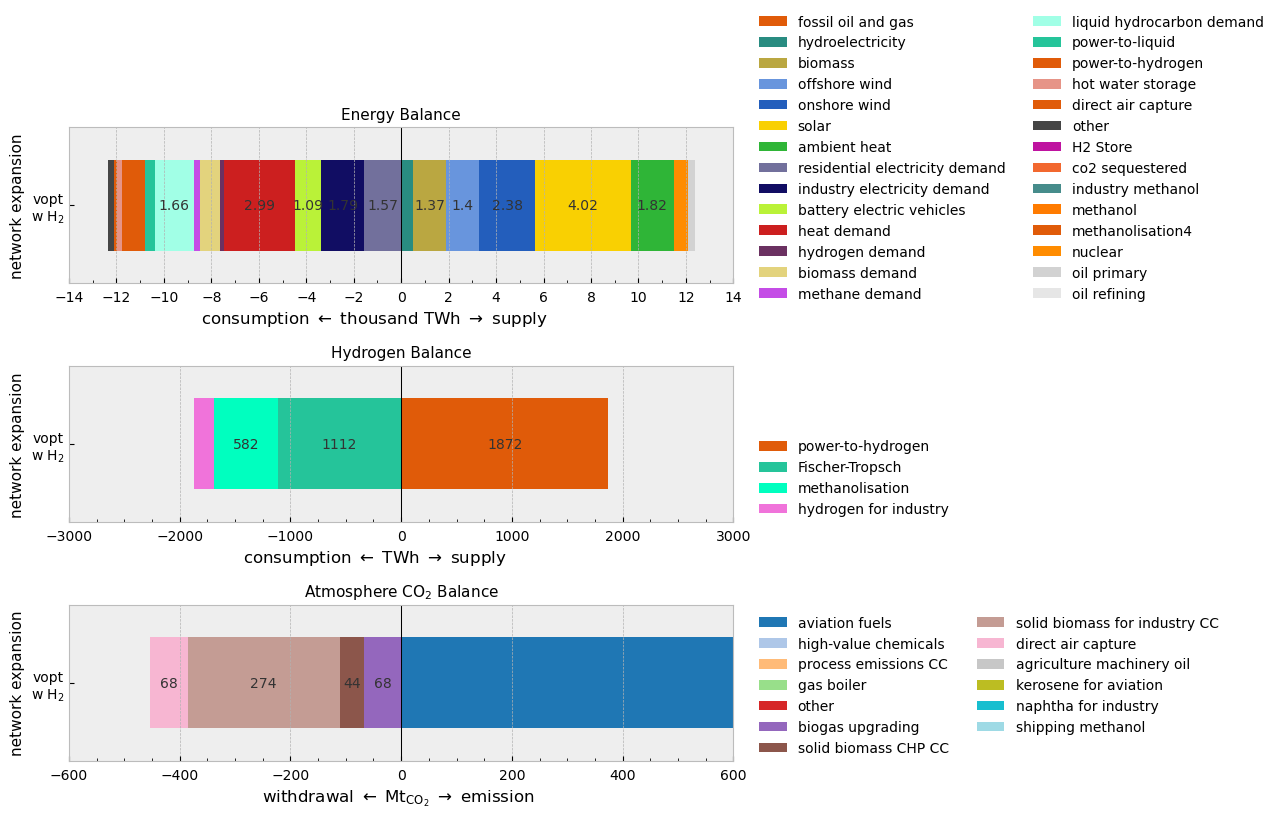

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(13, 8))

lim = 14.000
e.T.div(1e3).plot.barh(
    ax=ax1, width=0.7, stacked=True, color=tech_colors, xlim=(-lim, lim)
)

c.T.plot.barh(ax=ax3, width=0.7, stacked=True, cmap="tab20", xlim=(-600, 600))

h.T.plot.barh(ax=ax2, width=0.7, stacked=True, color=tech_colors, xlim=(-3000, 3000))

ax1.legend(loc=(1.03, -0.15), ncol=2)
ax2.legend(loc=(1.03, 0), ncol=1)
ax3.legend(loc=(1.03, 0), ncol=2)

ax1.set_xticks(np.arange(-lim, lim + 1, 2))
ax1.set_xticks(np.arange(-lim, lim + 1, 1), minor=True)
ax2.set_xticks(np.arange(-3000, 3001, 250), minor=True)
ax3.set_xticks(np.arange(-600, 601, 50), minor=True)

for ax, thresh, dec in zip([ax1, ax2, ax3], [1, 200, 30], [2, 0, 0]):
    # for tick in ax.get_xticklabels():
    #    tick.set_rotation(90)
    ax.axvline(0, color="k", linewidth=0.75)
    ax.xaxis.set_tick_params(pad=5)
    ax.set_ylabel("network expansion", fontsize=11)
    ax.grid(axis="x")

    for bars in ax.containers:
        labels = [
            np.round(abs(v), dec) if abs(v) > thresh else "" for v in bars.datavalues
        ]
        if not dec:
            labels = [f"{l:.0f}" if isinstance(l, float) else l for l in labels]
        ax.bar_label(
            bars, labels=labels, label_type="center", color="#333333", fontsize=10
        )

ax1.set_xlabel(r"consumption $\leftarrow$ thousand TWh $\rightarrow$ supply           ")
ax3.set_xlabel(r"withdrawal $\leftarrow$ Mt$_{CO_2}$ $\rightarrow$ emission  ")
ax2.set_xlabel(r"consumption $\leftarrow$ TWh $\rightarrow$ supply           ")

ax1.set_title("Energy Balance", fontsize=11)
ax3.set_title(r"Atmosphere CO$_2$ Balance", fontsize=11)
ax2.set_title("Hydrogen Balance", fontsize=11)

plt.tight_layout()

plt.savefig(OUTPUT + "balance-h.pdf", bbox_inches="tight")